In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("/content/drive/MyDrive/CMSC498E/evaluation_results.csv")
df.tail()

,Filename,Loss_Type,Subject,Object,Action,Mode,L2_Error_mm,Jerk,Contact_Pts,Penetration,Self_Collision_%
100,allegro_sdfloss_s1_cup_drink_1_nn.npy,sdfloss,s1,cup,drink_1,nn,5.85,0.002849,0.74,0.26,0.0
101,allegro_sdfloss_s1_cylinderlarge_inspect_1_nn.npy,sdfloss,s1,cylinderlarge,inspect_1,nn,4.12,0.003704,0.32,1.05,0.0
102,allegro_sdfloss_s1_cylindermedium_inspect_1_nn...,sdfloss,s1,cylindermedium,inspect_1,nn,5.58,0.004449,0.56,0.42,0.0
103,allegro_sdfloss_s1_cylindersmall_inspect_1_nn.npy,sdfloss,s1,cylindersmall,inspect_1,nn,4.27,0.003782,0.66,0.34,0.0
104,allegro_sdfloss_s1_doorknob_use_1_nn.npy,sdfloss,s1,doorknob,use_1,nn,3.78,0.002673,0.50,0.00,0.0


In [4]:
df = df.drop(columns=['Self_Collision_%'])
df.head()

,Filename,Loss_Type,Subject,Object,Action,Mode,L2_Error_mm,Jerk,Contact_Pts,Penetration
0,allegro_allloss_s1_airplane_fly_1_nn.npy,allloss,s1,airplane,fly_1,nn,11.39,0.002538,0.67,0.08
1,allegro_allloss_s1_alarmclock_lift_nn.npy,allloss,s1,alarmclock,lift,nn,12.20,0.003606,0.58,0.00
2,allegro_allloss_s1_apple_eat_1_nn.npy,allloss,s1,apple,eat_1,nn,7.87,0.003152,0.93,1.74
3,allegro_allloss_s1_banana_eat_1_nn.npy,allloss,s1,banana,eat_1,nn,8.65,0.003826,0.27,0.02
4,allegro_allloss_s1_binoculars_lift_nn.npy,allloss,s1,binoculars,lift,nn,8.20,0.004770,0.64,0.71


### Comparison of 'nn', 'drop', and 'simple' Modes for 'originalloss' Loss_Type

In [5]:
# Filter the DataFrame for 'originalloss' and specific modes
originalloss_comp = df[(df['Loss_Type'] == 'originalloss') & (df['Mode'].isin(['drop', 'simple', 'nn']))]

# Define metrics (excluding 'Self_Collision_%' which was already dropped)
metrics = ['L2_Error_mm', 'Jerk', 'Contact_Pts', 'Penetration']

print("**1. Average Comparison for 'originalloss' - Drop, Simple, and NN Modes:**")
# Calculate the mean for each metric, grouped by 'Mode'
average_originalloss_comp = originalloss_comp.groupby('Mode')[metrics].mean()
display(average_originalloss_comp)

**1. Average Comparison for 'originalloss' - Drop, Simple, and NN Modes:**


,L2_Error_mm,Jerk,Contact_Pts,Penetration
Mode,,,,
drop,10.716667,0.001941,0.510667,0.396667
nn,8.158667,0.002089,0.536000,0.442667
simple,10.136000,0.002025,0.510000,0.395333


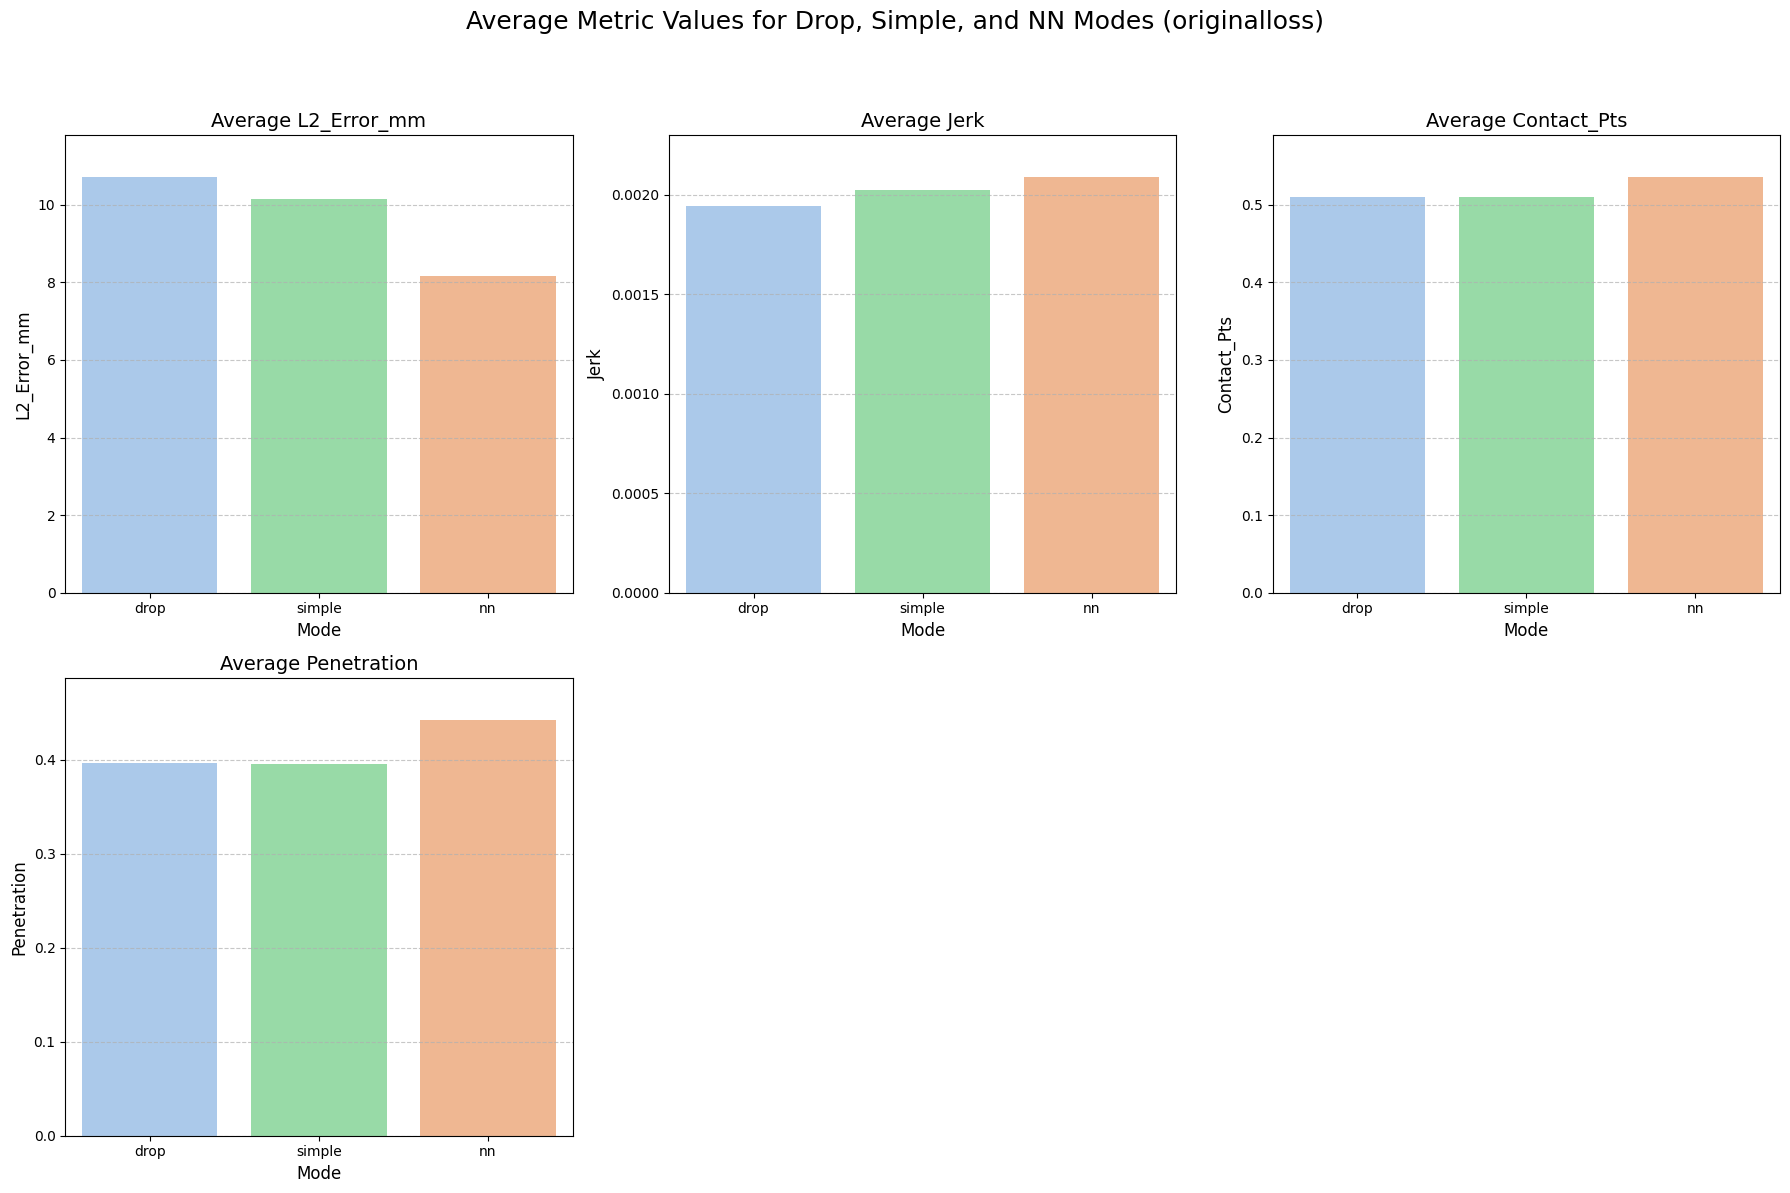

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a pastel color palette with exactly 3 colors for the three modes
pastel_palette = sns.color_palette("pastel", n_colors=3)
sns.set_palette(pastel_palette)

plt.figure(figsize=(18, 12))
plt.suptitle('Average Metric Values for Drop, Simple, and NN Modes (originalloss)', fontsize=18, y=1.02)

# Calculate max value for each metric to set a sensible y_limit dynamically
max_values = average_originalloss_comp[metrics].max()

# Define the desired order for the modes
mode_order = ['drop', 'simple', 'nn']

for i, metric in enumerate(metrics):
    plt.subplot(2, 3, i + 1) # Arrange plots in 2 rows, 3 columns
    sns.barplot(x=average_originalloss_comp.index, y=average_originalloss_comp[metric], palette=pastel_palette, hue=average_originalloss_comp.index, legend=False, order=mode_order)
    plt.title(f'Average {metric}', fontsize=14)
    plt.ylabel(metric, fontsize=12)
    plt.xlabel('Mode', fontsize=12)
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Set y-axis limits to make differences more apparent, starting from 0 for bar plots
    y_max = max_values[metric] * 1.1 # Add a 10% buffer to the max value
    plt.ylim(0, y_max)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

### 'First Place' Count Comparison for Drop, Simple, and NN Modes (originalloss)

**'First Place' Count per Metric for 'originalloss':**


,L2_Error_mm,Jerk,Contact_Pts,Penetration
drop,0,8,6,10
simple,2,3,5,12
nn,13,4,10,6


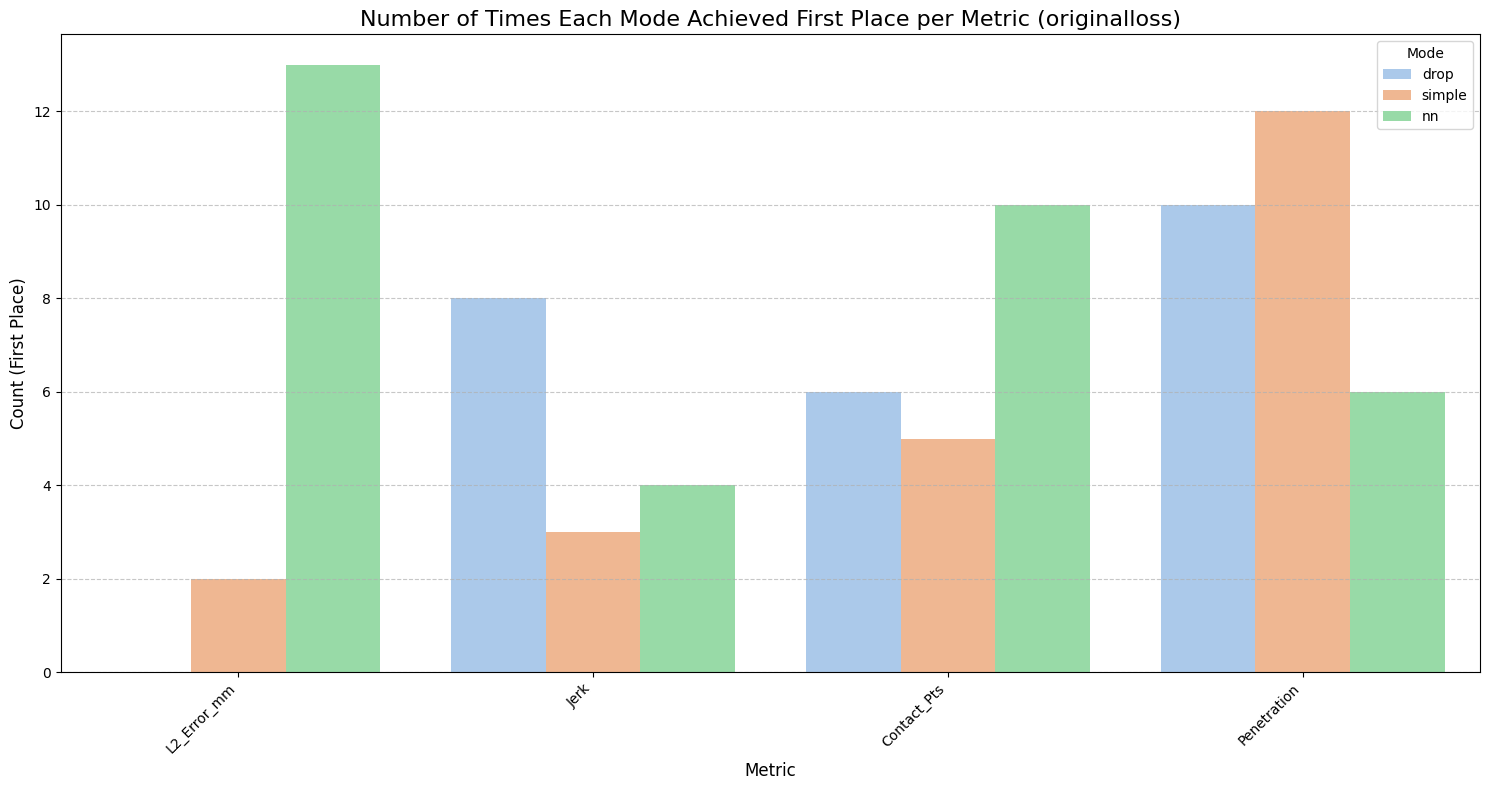

In [8]:
# Create a 'Base_ID' for each unique sample (e.g., 'airplane_fly_1') for originalloss_comp
originalloss_comp = originalloss_comp.copy()
originalloss_comp['Base_ID'] = originalloss_comp['Filename'].str.replace('_drop.npy', '', regex=False).str.replace('_simple.npy', '', regex=False).str.replace('_nn.npy', '', regex=False)

# Define what 'beats' means for each metric (lower is better for error/jerk/penetration, higher is better for contact points)
BETTER_IS_LOWER = ['L2_Error_mm', 'Jerk', 'Penetration']
BETTER_IS_HIGHER = ['Contact_Pts']

# Separate data for each mode within originalloss_comp
drop_data_originalloss = originalloss_comp[originalloss_comp['Mode'] == 'drop'].set_index('Base_ID')
simple_data_originalloss = originalloss_comp[originalloss_comp['Mode'] == 'simple'].set_index('Base_ID')
nn_data_originalloss = originalloss_comp[originalloss_comp['Mode'] == 'nn'].set_index('Base_ID')

# Merge them on Base_ID for direct comparison
comparison_originalloss_df = drop_data_originalloss[metrics].add_suffix('_drop').merge(
    simple_data_originalloss[metrics].add_suffix('_simple'),
    left_index=True,
    right_index=True
).merge(
    nn_data_originalloss[metrics].add_suffix('_nn'),
    left_index=True,
    right_index=True
)

print("**'First Place' Count per Metric for 'originalloss':**")

# Initialize a dictionary to store counts for each mode
first_place_counts_originalloss = {mode: {metric: 0 for metric in metrics} for mode in ['drop', 'simple', 'nn']}

# Iterate through each metric and compare the three modes
for metric in metrics:
    drop_col = f'{metric}_drop'
    simple_col = f'{metric}_simple'
    nn_col = f'{metric}_nn'

    for index, row in comparison_originalloss_df.iterrows():
        drop_val = row[drop_col]
        simple_val = row[simple_col]
        nn_val = row[nn_col]

        if metric in BETTER_IS_LOWER:
            # Lower value is better
            min_val = min(drop_val, simple_val, nn_val)
            if drop_val == min_val: first_place_counts_originalloss['drop'][metric] += 1
            if simple_val == min_val: first_place_counts_originalloss['simple'][metric] += 1
            if nn_val == min_val: first_place_counts_originalloss['nn'][metric] += 1
        elif metric in BETTER_IS_HIGHER:
            # Higher value is better
            max_val = max(drop_val, simple_val, nn_val)
            if drop_val == max_val: first_place_counts_originalloss['drop'][metric] += 1
            if simple_val == max_val: first_place_counts_originalloss['simple'][metric] += 1
            if nn_val == max_val: first_place_counts_originalloss['nn'][metric] += 1

# Convert to DataFrame for better display
first_place_df_originalloss = pd.DataFrame.from_dict(first_place_counts_originalloss, orient='index')
display(first_place_df_originalloss)

# Plot for 'First Place' counts using seaborn for better palette control
plt.figure(figsize=(15, 8))
# Prepare data for seaborn.barplot: unstacking and resetting index for easier plotting
plot_df_originalloss = first_place_df_originalloss.T.reset_index().melt('index', var_name='Mode', value_name='Count')
sns.barplot(x='index', y='Count', hue='Mode', data=plot_df_originalloss, palette='pastel')
plt.title("Number of Times Each Mode Achieved First Place per Metric (originalloss)", fontsize=16)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Count (First Place)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Mode')
plt.tight_layout()
plt.show()

### Comparison of Five Loss_Types for 'nn' Mode

In [9]:
# Filter the DataFrame to include only 'nn' mode
nn_mode_comp = df[df['Mode'] == 'nn']

# Define metrics
metrics = ['L2_Error_mm', 'Jerk', 'Contact_Pts', 'Penetration']

print("**1. Average Comparison for Five Loss_Types in 'nn' Mode:**")
# Calculate the mean for each metric, grouped by 'Loss_Type'
average_nn_mode_comp = nn_mode_comp.groupby('Loss_Type')[metrics].mean()
display(average_nn_mode_comp)

**1. Average Comparison for Five Loss_Types in 'nn' Mode:**


,L2_Error_mm,Jerk,Contact_Pts,Penetration
Loss_Type,,,,
allloss,9.696667,0.003736,0.520667,0.434667
attloss,24.378000,0.013504,0.428667,0.360000
limitloss,9.696667,0.003736,0.520667,0.434667
originalloss,8.158667,0.002089,0.536000,0.442667
sdfloss,5.610000,0.004731,0.540667,0.438667


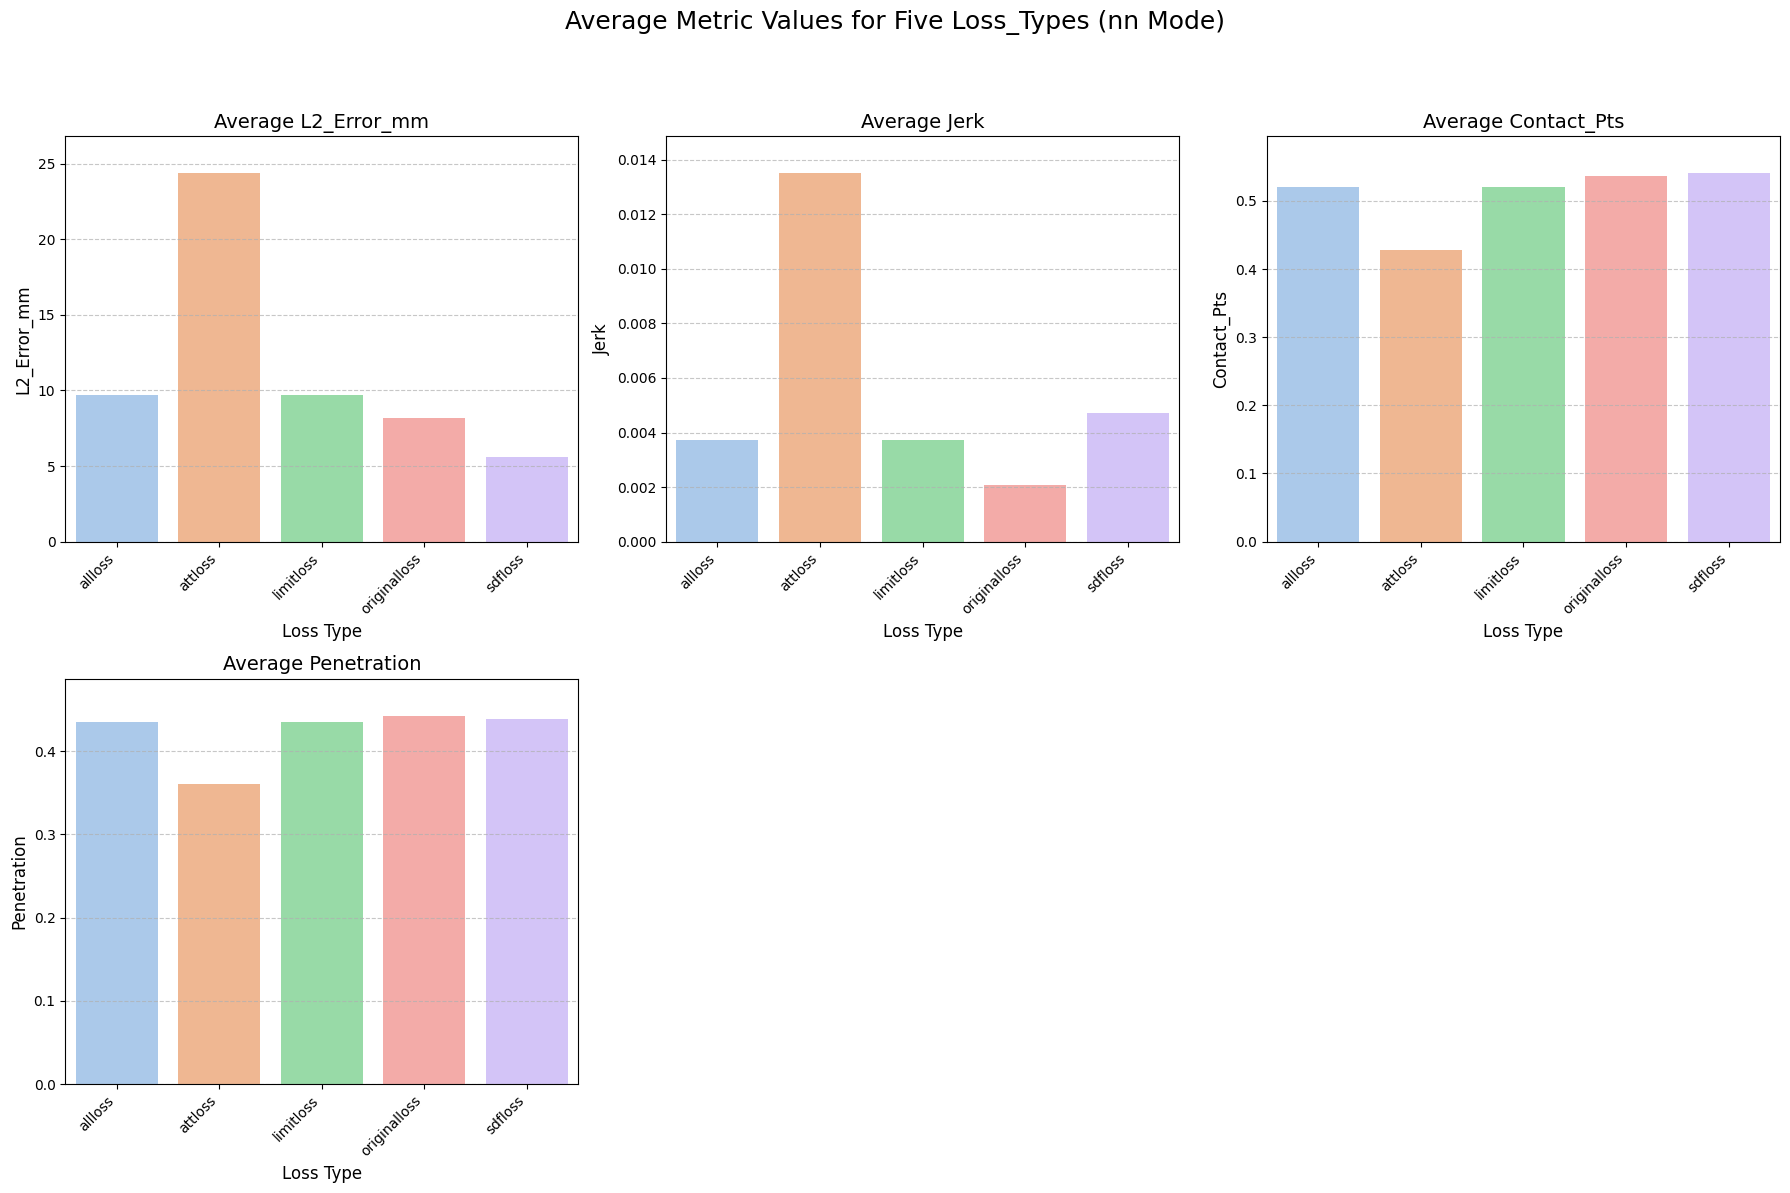

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the number of unique Loss_Types for 'nn' mode
num_loss_types = len(nn_mode_comp['Loss_Type'].unique())
pastel_palette = sns.color_palette("pastel", n_colors=num_loss_types)
sns.set_palette(pastel_palette)

plt.figure(figsize=(18, 12))
plt.suptitle('Average Metric Values for Five Loss_Types (nn Mode)', fontsize=18, y=1.02)

# Calculate max value for each metric to set a sensible y_limit dynamically
max_values = average_nn_mode_comp[metrics].max()

# Define the desired order for the Loss_Types (optional, but good for consistency)
# Assuming the user wants to see them as they appear in the data or alphabetically
loss_type_order = average_nn_mode_comp.index.tolist()

for i, metric in enumerate(metrics):
    plt.subplot(2, 3, i + 1) # Arrange plots in 2 rows, 3 columns
    sns.barplot(x=average_nn_mode_comp.index, y=average_nn_mode_comp[metric], palette=pastel_palette, hue=average_nn_mode_comp.index, legend=False, order=loss_type_order)
    plt.title(f'Average {metric}', fontsize=14)
    plt.ylabel(metric, fontsize=12)
    plt.xlabel('Loss Type', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Set y-axis limits to make differences more apparent, starting from 0 for bar plots
    y_max = max_values[metric] * 1.1 # Add a 10% buffer to the max value
    plt.ylim(0, y_max)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

### 'First Place' Count Comparison for Five Loss_Types (nn Mode)

**'First Place' Count per Metric for Five Loss_Types in 'nn' Mode:**


,L2_Error_mm,Jerk,Contact_Pts,Penetration
allloss,0,0,3,6
attloss,0,0,1,12
limitloss,0,0,3,6
originalloss,0,15,8,3
sdfloss,15,0,7,6


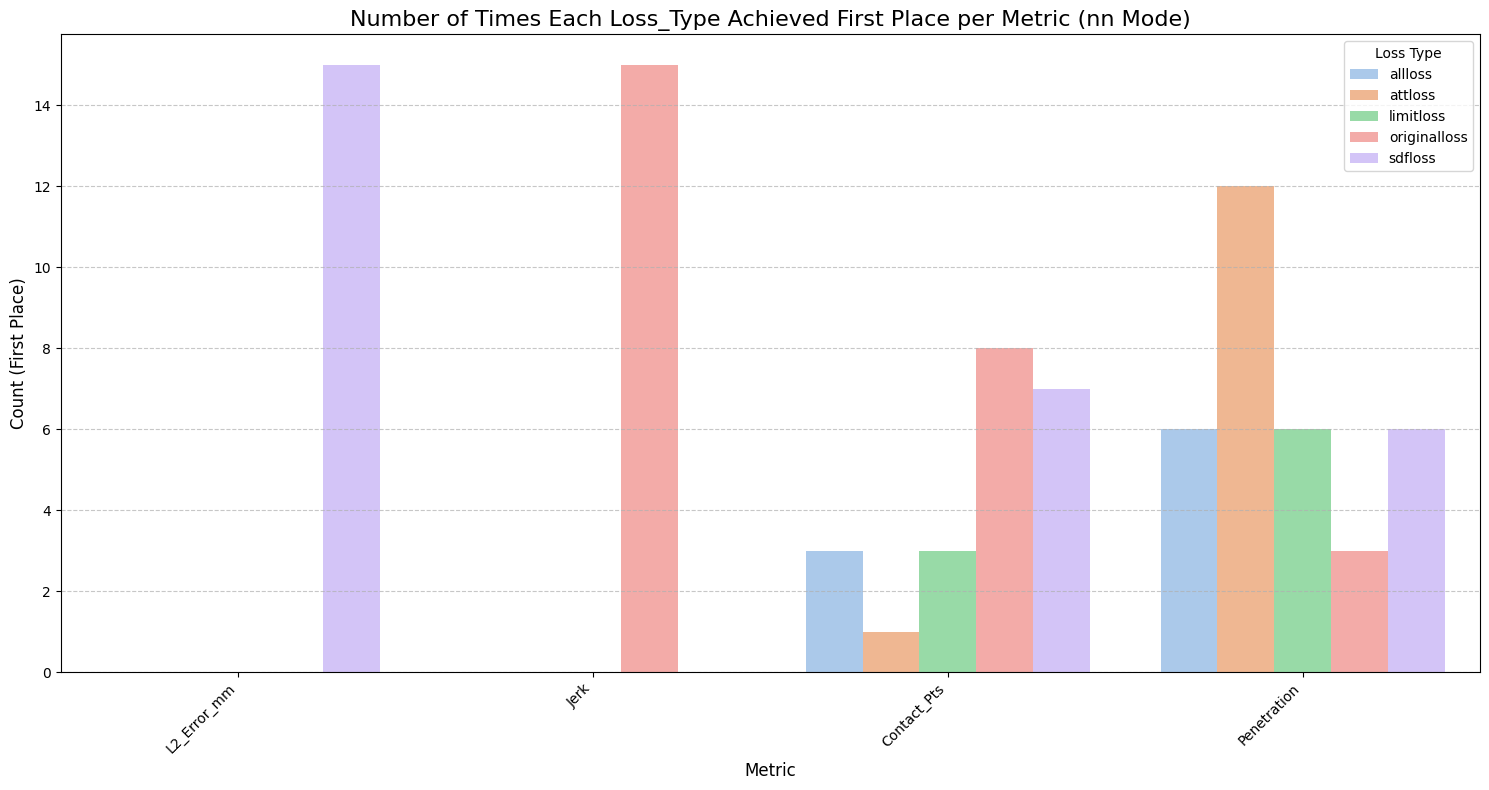

In [12]:
# Create a copy to avoid SettingWithCopyWarning
nn_mode_comp_copy = nn_mode_comp.copy()

# Correctly create a 'Base_ID' for each unique sample, independent of Loss_Type
nn_mode_comp_copy['Base_ID'] = nn_mode_comp_copy['Subject'] + '_' + nn_mode_comp_copy['Object'] + '_' + nn_mode_comp_copy['Action']

# Define what 'beats' means for each metric (lower is better for error/jerk/penetration, higher is better for contact points)
# Reusing definitions from previous analysis
BETTER_IS_LOWER = ['L2_Error_mm', 'Jerk', 'Penetration']
BETTER_IS_HIGHER = ['Contact_Pts']

print("**'First Place' Count per Metric for Five Loss_Types in 'nn' Mode:**")

# Initialize a dictionary to store counts for each Loss_Type
# Get all unique Loss_Types present in the nn_mode_comp_copy
all_loss_types = nn_mode_comp_copy['Loss_Type'].unique().tolist()
first_place_counts_losstype = {lt: {metric: 0 for metric in metrics} for lt in all_loss_types}

# Iterate through each unique Base_ID (sample)
for base_id in nn_mode_comp_copy['Base_ID'].unique():
    # Filter data for the current Base_ID
    current_sample_data = nn_mode_comp_copy[nn_mode_comp_copy['Base_ID'] == base_id]

    for metric in metrics:
        # Get the metric values for all Loss_Types for this sample
        metric_values = current_sample_data.set_index('Loss_Type')[metric]

        if not metric_values.empty:
            if metric in BETTER_IS_LOWER:
                min_val = metric_values.min()
                winning_loss_types = metric_values[metric_values == min_val].index.tolist()
            elif metric in BETTER_IS_HIGHER:
                max_val = metric_values.max()
                winning_loss_types = metric_values[metric_values == max_val].index.tolist()
            else:
                winning_loss_types = [] # Should not happen with defined metrics

            # Increment counts for winning Loss_Types (handles ties)
            # If multiple loss types are tied for first place, each gets a point
            for lt in winning_loss_types:
                first_place_counts_losstype[lt][metric] += 1

# Convert to DataFrame for better display
first_place_df_losstype = pd.DataFrame.from_dict(first_place_counts_losstype, orient='index')
display(first_place_df_losstype)

# Plot for 'First Place' counts using seaborn
plt.figure(figsize=(15, 8))
# Prepare data for seaborn.barplot
plot_df_losstype = first_place_df_losstype.T.reset_index().melt('index', var_name='Loss_Type', value_name='Count')
num_loss_types_plot = len(all_loss_types)
pastel_palette_plot = sns.color_palette("pastel", n_colors=num_loss_types_plot)
sns.barplot(x='index', y='Count', hue='Loss_Type', data=plot_df_losstype, palette=pastel_palette_plot)
plt.title("Number of Times Each Loss_Type Achieved First Place per Metric (nn Mode)", fontsize=16)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Count (First Place)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Loss Type')
plt.tight_layout()
plt.show()